## Maria Alexeenko 337982318 , Ilay Sabach 315377788 , Victoria Golovitsky 211491980

# Part C - Search (חלק ג' - חיפוש)

In [4]:
!pip install spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 163.8 kB/s eta 0:01:18
     --------------------------------------- 0.0/12.8 MB 178.6 kB/s eta 0:01:12
     --------------------------------------- 0.1/12.8 MB 286.7 kB/s eta 0:00:45
     --------------------------------------- 0.1/12.8 MB 379.3 kB/s eta 0:00:34
      -------------------------------------- 0.2/12.8 MB 599.0 kB/s eta 0:00:22
      -------------------------------------- 0.3/12.8 MB 682.7 kB/s eta 0:00:19
     - -------------------------------------- 0.5/12.8 MB 1.1 MB/s eta 0:00:11
     -- ------------------------------------- 0.7/12.8 MB 1.4 MB/s eta 0:00:09
  


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import json
import numpy as np
import pandas as pd
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

nlp = spacy.load("en_core_web_sm")

## Data Loading

In [6]:
# Load Documents
with open('all_docs_8.jsonl', 'r', encoding='utf-8') as f:
    docs = [json.loads(line) for line in f]

# Load Queries
with open('queries_8.jsonl', 'r', encoding='utf-8') as f:
    queries = [json.loads(line) for line in f]

# Load Relevance Judgments (Gold Standard)
qrels = {}
with open('qrel_8.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        qrels[item['query_id']] = set(item['rel_docs'])

doc_ids = [d['doc_id'] for d in docs]

print(f"Loaded {len(docs)} documents")
print(f"Loaded {len(queries)} queries")
print(f"Loaded {len(qrels)} relevance judgments")
print(f"\nQuery IDs: {[q['query_id'] for q in queries]}")
relevant_per_query = {k: len(v) for k, v in qrels.items()}
print(f"Relevant docs per query: {relevant_per_query}")

Loaded 3000 documents
Loaded 5 queries
Loaded 5 relevance judgments

Query IDs: ['2', '7', '16', '36', '38']
Relevant docs per query: {'36': 220, '38': 304, '16': 110, '2': 65, '7': 78}


## Text Cleaning
Using the same cleaning pipeline from Parts A and B:
Tokenization → Lemmatization → Lowercasing → Remove stopwords, punctuation, URLs, non-alphabetic tokens.

In [ ]:
def clean_text(text):
    """
    Tokenization, Lowercasing, Lemmatization, and Noise Removal.
    """
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_url
        and token.text.strip() != ""
        and token.is_alpha
    ]
    return " ".join(tokens)

In [8]:
# Combine text fields
# Docs: Title + Abstract
doc_texts = [f"{d['title']} {d['abstract']}" for d in docs]

# Queries: Title + Need + Context
query_texts = [f"{q['title']} {q['need']} {q['context']}" for q in queries]

print("Cleaning documents... (this may take a few minutes)")
cleaned_docs = [clean_text(txt) for txt in doc_texts]

print("Cleaning queries...")
cleaned_queries = [clean_text(txt) for txt in query_texts]

print(f"\nDone. Example cleaned query:")
print(f"Original: {query_texts[0][:120]}...")
print(f"Cleaned:  {cleaned_queries[0]}")

Cleaning documents... (this may take a few minutes)
Cleaning queries...

Done. Example cleaned query:
Original: Generating transgenic mice Find protocols for generating transgenic mice. Determine protocols to generate transgenic mic...
Cleaned:  generate transgenic mouse find protocol generate transgenic mouse determine protocol generate transgenic mouse have single copy gene interest specific location


## Vectorization
Building three vector representations:
1. **Binary** - presence/absence of each term (0/1)
2. **Frequency** - raw term count per document
3. **TF-IDF** - Term Frequency × Inverse Document Frequency

In [9]:
# Binary Representation
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(cleaned_docs)
Q_binary = binary_vectorizer.transform(cleaned_queries)

# Frequency Representation
freq_vectorizer = CountVectorizer()
X_freq = freq_vectorizer.fit_transform(cleaned_docs)
Q_freq = freq_vectorizer.transform(cleaned_queries)

# TF-IDF Representation
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(cleaned_docs)
Q_tfidf = tfidf_vectorizer.transform(cleaned_queries)

print(f"Vocabulary size: {len(binary_vectorizer.get_feature_names_out())}")
print(f"Document matrix shape: {X_tfidf.shape}")
print(f"Query matrix shape: {Q_tfidf.shape}")

Vocabulary size: 18574
Document matrix shape: (3000, 18574)
Query matrix shape: (5, 18574)


---
## Question 1: Cosine Similarity Search - All Representations
We compute the cosine similarity between each query and all 3000 documents, for each of the three representations (Binary, Frequency, TF-IDF). We then rank documents by similarity and retrieve the top 100.

In [10]:
# Compute cosine similarity matrices for all representations
cos_sim_binary = cosine_similarity(Q_binary, X_binary)
cos_sim_freq = cosine_similarity(Q_freq, X_freq)
cos_sim_tfidf = cosine_similarity(Q_tfidf, X_tfidf)

representations = {
    'Binary': cos_sim_binary,
    'Frequency': cos_sim_freq,
    'TF-IDF': cos_sim_tfidf
}

print(f"Cosine similarity matrix shape (queries x docs): {cos_sim_binary.shape}")

Cosine similarity matrix shape (queries x docs): (5, 3000)


In [11]:
def get_top_k(cos_sim_matrix, query_idx, doc_ids, k=100):
    """Returns top-k documents sorted by cosine similarity for a given query."""
    similarities = cos_sim_matrix[query_idx]
    top_indices = np.argsort(similarities)[::-1][:k]
    return [(doc_ids[i], similarities[i]) for i in top_indices]


# Retrieve top 100 for every query and every representation
all_results = {}
for rep_name, cos_sim_matrix in representations.items():
    all_results[rep_name] = {}
    for q_idx, query in enumerate(queries):
        q_id = query['query_id']
        all_results[rep_name][q_id] = get_top_k(cos_sim_matrix, q_idx, doc_ids, k=100)

print("Search completed for all representations.")

Search completed for all representations.


In [12]:
# Display top 10 results per query for each representation
for rep_name in representations:
    print(f"\n{'=' * 70}")
    print(f"  {rep_name} Representation — Top 10 Results per Query")
    print(f"{'=' * 70}")

    for q_idx, query in enumerate(queries):
        q_id = query['query_id']
        results = all_results[rep_name][q_id]

        print(f"\nQuery {q_id}: \"{query['title']}\"")
        print(f"{'Rank':<6} {'Doc ID':<12} {'Cosine Similarity':<20}")
        print("-" * 38)
        for rank, (did, score) in enumerate(results[:10], 1):
            print(f"{rank:<6} {did:<12} {score:.6f}")


  Binary Representation — Top 10 Results per Query

Query 2: "Generating transgenic mice"
Rank   Doc ID       Cosine Similarity   
--------------------------------------
1      10586711     0.339683
2      10840731     0.320256
3      11786607     0.280224
4      9108537      0.277350
5      10625648     0.273115
6      9379961      0.248069
7      11357663     0.240192
8      11065338     0.237826
9      10949829     0.235339
10     8799155      0.230408

Query 7: "DNA repair and oxidative stress"
Rank   Doc ID       Cosine Similarity   
--------------------------------------
1      10554559     0.447214
2      8657653      0.424264
3      8948932      0.424264
4      11436318     0.424264
5      11579558     0.424264
6      11436303     0.365148
7      11186001     0.358569
8      9325246      0.335410
9      9056893      0.335410
10     12013846     0.316228

Query 16: "AAA proteins"
Rank   Doc ID       Cosine Similarity   
--------------------------------------
1      11309190    

### Cosine Similarity Matrix - Heatmap Visualization
Below we visualize the cosine similarity between queries and the top-ranked documents for each representation.

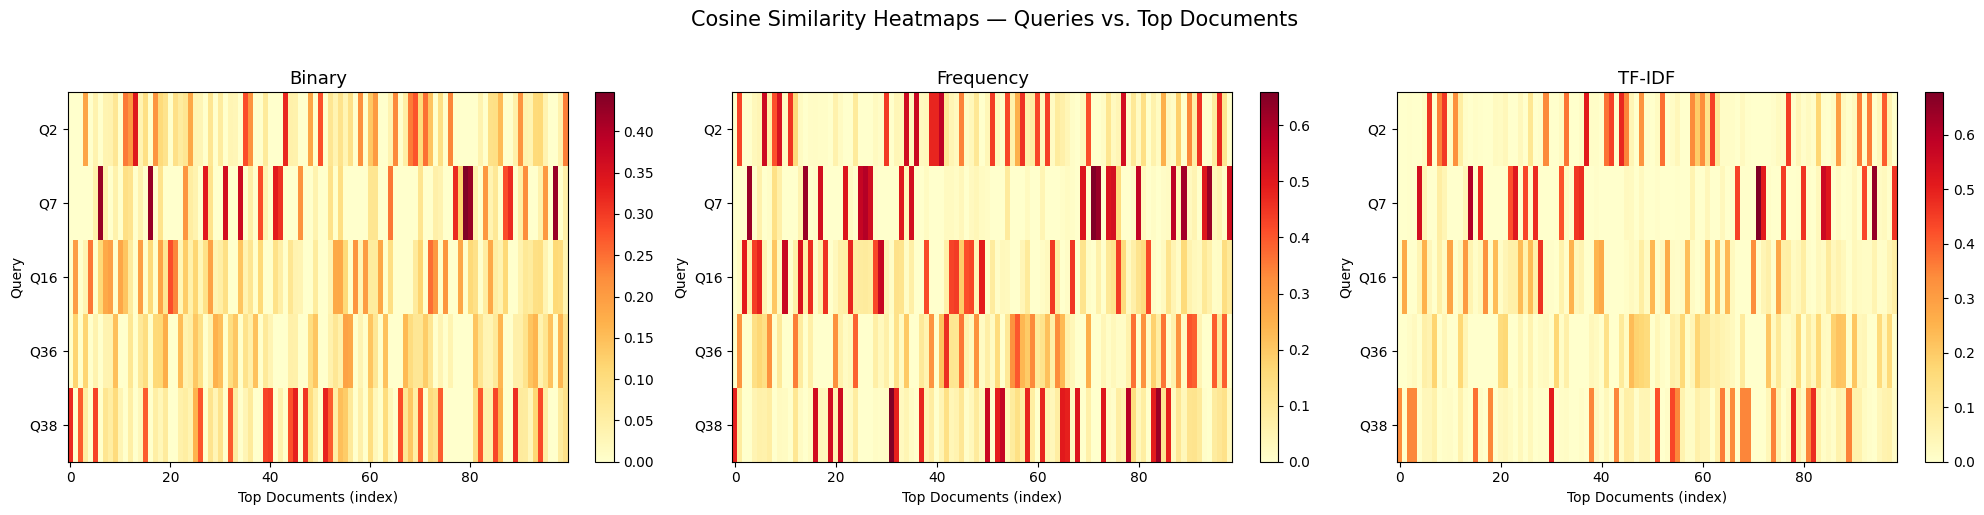

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
query_labels = [f"Q{q['query_id']}" for q in queries]

for ax, (rep_name, cos_sim_matrix) in zip(axes, representations.items()):
    # Collect top-20 document indices across all queries for display
    top_doc_indices = set()
    for q_idx in range(len(queries)):
        top_indices = np.argsort(cos_sim_matrix[q_idx])[::-1][:20]
        top_doc_indices.update(top_indices)
    top_doc_indices = sorted(top_doc_indices)

    sub_matrix = cos_sim_matrix[:, top_doc_indices]
    im = ax.imshow(sub_matrix, aspect='auto', cmap='YlOrRd')
    ax.set_title(f'{rep_name}', fontsize=13)
    ax.set_ylabel('Query')
    ax.set_xlabel('Top Documents (index)')
    ax.set_yticks(range(len(queries)))
    ax.set_yticklabels(query_labels)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Cosine Similarity Heatmaps — Queries vs. Top Documents', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Full cosine similarity matrix as DataFrame (queries to queries summary)
# Showing average similarity of top-100 retrieved docs per query for each representation
print("Average Cosine Similarity of Top-100 Retrieved Documents per Query:\n")

rows = []
for q_idx, query in enumerate(queries):
    q_id = query['query_id']
    row = {'Query ID': q_id, 'Query Title': query['title']}
    for rep_name, cos_sim_matrix in representations.items():
        top_100_scores = [score for _, score in all_results[rep_name][q_id]]
        row[f'{rep_name} (avg)'] = f"{np.mean(top_100_scores):.4f}"
        row[f'{rep_name} (max)'] = f"{top_100_scores[0]:.4f}"
        row[f'{rep_name} (min)'] = f"{top_100_scores[-1]:.4f}"
    rows.append(row)

sim_summary_df = pd.DataFrame(rows)
sim_summary_df

Average Cosine Similarity of Top-100 Retrieved Documents per Query:



,Query ID,Query Title,Binary (avg),Binary (max),Binary (min),Frequency (avg),Frequency (max),Frequency (min),TF-IDF (avg),TF-IDF (max),TF-IDF (min)
0,2,Generating transgenic mice,0.1612,0.3397,0.1214,0.2879,0.5697,0.1547,0.2182,0.5094,0.0938
1,7,DNA repair and oxidative stress,0.1815,0.4472,0.1110,0.3708,0.6547,0.1750,0.3037,0.6779,0.1168
2,16,AAA proteins,0.1597,0.2801,0.1323,0.3606,0.5516,0.2849,0.1875,0.4679,0.1267
3,36,RAB3A,0.1216,0.1890,0.0993,0.2677,0.4621,0.2064,0.1242,0.2323,0.0950
4,38,Risk factors for stroke,0.2399,0.3280,0.2042,0.4363,0.6588,0.3630,0.2941,0.5061,0.2277


---
## Question 2: TF-IDF Search - Full Top 100 Results
Below we present the complete list of 100 most relevant documents for each query, based on the TF-IDF cosine similarity.

In [15]:
# Build a lookup from doc_id -> title for enriched display
doc_title_map = {d['doc_id']: d['title'] for d in docs}

for q_idx, query in enumerate(queries):
    q_id = query['query_id']
    results = all_results['TF-IDF'][q_id]

    print(f"\n{'=' * 90}")
    print(f"  Query {q_id}: \"{query['title']}\"")
    print(f"  Need: {query['need']}")
    print(f"{'=' * 90}")

    result_rows = []
    for rank, (did, score) in enumerate(results, 1):
        result_rows.append({
            'Rank': rank,
            'Doc ID': did,
            'Cosine Similarity': round(score, 6),
            'Title': doc_title_map.get(did, 'N/A')[:80]
        })

    df = pd.DataFrame(result_rows)
    display(df)


  Query 2: "Generating transgenic mice"
  Need: Find protocols for generating transgenic mice.


,Rank,Doc ID,Cosine Similarity,Title
0,1,10840731,0.509432,Production of transgenic mice.
1,2,11891509,0.486877,Use of transgenic and knockout strategies in m...
2,3,9617206,0.468499,[Transgenic mice in basic research]
3,4,7927071,0.456975,[Production of transgenic mice]
4,5,10727777,0.452704,Single and multiple transgenic mice as models ...
...,...,...,...,...
95,96,10694580,0.097621,In vivo natural killer cell activities reveale...
96,97,9551904,0.097021,Adenovector-mediated expression of human throm...
97,98,11352570,0.096946,Elucidation of the minimal sequence required t...
98,99,7873888,0.096657,Localization of the peptidylglycine alpha-amid...



  Query 7: "DNA repair and oxidative stress"
  Need: Find correlation between DNA repair pathways and oxidative stress.


,Rank,Doc ID,Cosine Similarity,Title
0,1,10554559,0.677882,[Oxidative stress]
1,2,8948932,0.647533,[Changes in DNA induced by oxidative stress]
2,3,11579558,0.603947,[Repair mechanism of oxidative DNA damages]
3,4,11405881,0.560625,Oxidative stress and mechanisms of protection ...
4,5,11436318,0.543283,[DNA repair of oxidative damage in the mitocho...
...,...,...,...,...
95,96,10662214,0.133930,Benchmarks. Hernia repair best performers.
96,97,9085362,0.126647,The role of mitochondria in aging.
97,98,11430718,0.123798,Traumatic experiences and post-traumatic stres...
98,99,9784843,0.117604,EPC-K1 attenuates peroxynitrite-induced apopto...



  Query 16: "AAA proteins"
  Need: How do AAA proteins mediate interaction with lipids or DNA and what is their functional impact?


,Rank,Doc ID,Cosine Similarity,Title
0,1,9695811,0.467943,The AAA team: related ATPases with diverse fun...
1,2,11579565,0.333567,[AAA proteases]
2,3,11309190,0.325153,An AAA family tree.
3,4,8654588,0.306774,"Association of yeast SAP1, a novel member of t..."
4,5,9774689,0.281760,The human U5-220kD protein (hPrp8) forms a sta...
...,...,...,...,...
95,96,8758937,0.128891,Distinct domains of hTAFII100 are required for...
96,97,11343654,0.128741,Functional interaction of the active zone prot...
97,98,11795483,0.128120,The proteins of synaptic vesicle membranes are...
98,99,7488746,0.127200,Differential effect of functional olfactory de...



  Query 36: "RAB3A"
  Need: Background information on RAB3A.


,Rank,Doc ID,Cosine Similarity,Title
0,1,11350645,0.232303,Comparison of normal human skin gene expressio...
1,2,7711194,0.214576,Implementing transgenic and embryonic stem cel...
2,3,11517266,0.211718,Rab3A is required for brain-derived neurotroph...
3,4,11269644,0.210491,DNA microarrays in pediatric cancer.
4,5,11031229,0.208981,Mechanisms of synaptic vesicle exocytosis.
...,...,...,...,...
95,96,8137309,0.096114,The pathway regulating GADD153 induction in re...
96,97,8824407,0.095809,Proteins involved in synaptic vesicle docking ...
97,98,11305360,0.095746,A one-step gene amplification system for use i...
98,99,11891509,0.095544,Use of transgenic and knockout strategies in m...



  Query 38: "Risk factors for stroke"
  Need: Information concerning genetic loci that are associated with increased risk of stroke, such as apolipoprotein E4 or factor V mutations.


,Rank,Doc ID,Cosine Similarity,Title
0,1,10696659,0.506093,[From the genetics to the prevention of stroke]
1,2,9511873,0.491665,Genetics of stroke--a review.
2,3,9099529,0.477962,Genetic stroke risk factors.
3,4,12142561,0.436574,Genetic aspects of stroke: human and experimen...
4,5,9506595,0.420339,Risk of stroke in young women and two prothrom...
...,...,...,...,...
95,96,10702702,0.233726,Genetic risk factors in acute coronary disease.
96,97,11334615,0.233554,Joint effect of G1691A factor V point mutation...
97,98,9708966,0.230447,Is hormone replacement a risk factor for ische...
98,99,8743896,0.228346,Apolipoprotein E as a risk factor for coronary...


---
## Question 3: Evaluation - Precision, Recall, F1
We evaluate the search results by comparing the top-100 retrieved documents against the gold standard relevance judgments (`qrel_8.jsonl`).

- **Precision** = TP / |Retrieved| - what fraction of retrieved documents are truly relevant
- **Recall** = TP / |Relevant| - what fraction of all relevant documents were retrieved
- **F1** = 2 × Precision × Recall / (Precision + Recall) - harmonic mean

In [16]:
def calc_precision_recall_f1(retrieved_ids, relevant_ids):
    """Calculate Precision, Recall, and F1-score."""
    retrieved_set = set(retrieved_ids)
    relevant_set = set(relevant_ids)
    tp = len(retrieved_set & relevant_set)

    precision = tp / len(retrieved_set) if retrieved_set else 0.0
    recall = tp / len(relevant_set) if relevant_set else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return precision, recall, f1

In [17]:
evaluation_results = {}

for rep_name in representations:
    evaluation_results[rep_name] = {}

    print(f"\n{'=' * 60}")
    print(f"  Evaluation: {rep_name} Representation")
    print(f"{'=' * 60}")
    print(f"{'Query':<8} {'|Relevant|':<12} {'TP':<6} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 62)

    for query in queries:
        q_id = query['query_id']
        retrieved = [did for did, _ in all_results[rep_name][q_id]]
        relevant = qrels.get(q_id, set())

        precision, recall, f1 = calc_precision_recall_f1(retrieved, relevant)
        tp = len(set(retrieved) & relevant)

        evaluation_results[rep_name][q_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp,
            'relevant_count': len(relevant)
        }

        print(f"{q_id:<8} {len(relevant):<12} {tp:<6} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")

    # Averages
    avg_p = np.mean([v['precision'] for v in evaluation_results[rep_name].values()])
    avg_r = np.mean([v['recall'] for v in evaluation_results[rep_name].values()])
    avg_f1 = np.mean([v['f1'] for v in evaluation_results[rep_name].values()])
    print("-" * 62)
    print(f"{'AVG':<8} {'':<12} {'':<6} {avg_p:<12.4f} {avg_r:<12.4f} {avg_f1:<12.4f}")


  Evaluation: Binary Representation
Query    |Relevant|   TP     Precision    Recall       F1          
--------------------------------------------------------------
2        65           49     0.4900       0.7538       0.5939      
7        78           76     0.7600       0.9744       0.8539      
16       110          49     0.4949       0.4455       0.4689      
36       220          15     0.1500       0.0682       0.0937      
38       304          98     0.9800       0.3224       0.4851      
--------------------------------------------------------------
AVG                          0.5750       0.5128       0.4991      

  Evaluation: Frequency Representation
Query    |Relevant|   TP     Precision    Recall       F1          
--------------------------------------------------------------
2        65           61     0.6100       0.9385       0.7394      
7        78           77     0.7700       0.9872       0.8652      
16       110          35     0.3535       0.3182      

In [18]:
# Summary table as DataFrame
summary_rows = []
for rep_name in representations:
    for query in queries:
        q_id = query['query_id']
        e = evaluation_results[rep_name][q_id]
        summary_rows.append({
            'Representation': rep_name,
            'Query ID': q_id,
            'Query Title': query['title'],
            '|Relevant|': e['relevant_count'],
            'TP': e['tp'],
            'Precision': round(e['precision'], 4),
            'Recall': round(e['recall'], 4),
            'F1': round(e['f1'], 4)
        })

eval_df = pd.DataFrame(summary_rows)
print("Full Evaluation Summary:")
display(eval_df)

Full Evaluation Summary:


,Representation,Query ID,Query Title,|Relevant|,TP,Precision,Recall,F1
0,Binary,2,Generating transgenic mice,65,49,0.4900,0.7538,0.5939
1,Binary,7,DNA repair and oxidative stress,78,76,0.7600,0.9744,0.8539
2,Binary,16,AAA proteins,110,49,0.4949,0.4455,0.4689
3,Binary,36,RAB3A,220,15,0.1500,0.0682,0.0937
4,Binary,38,Risk factors for stroke,304,98,0.9800,0.3224,0.4851
5,Frequency,2,Generating transgenic mice,65,61,0.6100,0.9385,0.7394
6,Frequency,7,DNA repair and oxidative stress,78,77,0.7700,0.9872,0.8652
7,Frequency,16,AAA proteins,110,35,0.3535,0.3182,0.3349
8,Frequency,36,RAB3A,220,5,0.0500,0.0227,0.0313
9,Frequency,38,Risk factors for stroke,304,100,1.0000,0.3289,0.4950


---
## Question 4: Visualization & Analysis

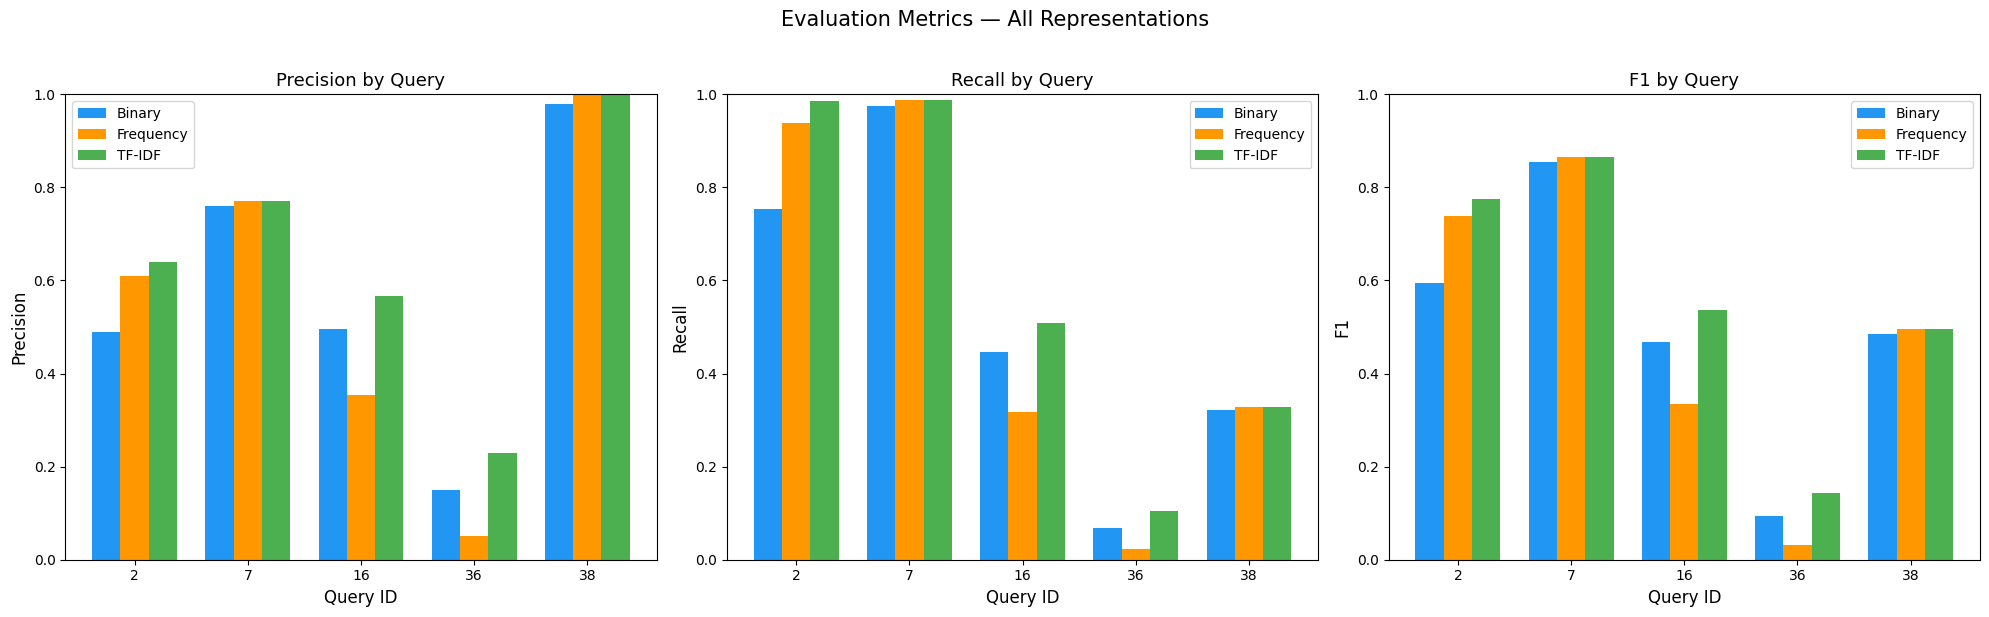

In [19]:
# Bar charts: Precision, Recall, F1 per query grouped by representation
query_ids = [q['query_id'] for q in queries]
x = np.arange(len(query_ids))
width = 0.25
rep_names = list(representations.keys())
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric in zip(axes, ['precision', 'recall', 'f1']):
    for i, rep_name in enumerate(rep_names):
        values = [evaluation_results[rep_name][q_id][metric] for q_id in query_ids]
        ax.bar(x + i * width, values, width, label=rep_name, color=colors[i])

    ax.set_xlabel('Query ID', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_title(f'{metric.capitalize()} by Query', fontsize=13)
    ax.set_xticks(x + width)
    ax.set_xticklabels(query_ids)
    ax.legend()
    ax.set_ylim(0, 1.0)

plt.suptitle('Evaluation Metrics — All Representations', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Average Metrics Across All Queries:


,Precision,Recall,F1
Binary,0.5750,0.5128,0.4991
Frequency,0.5567,0.5191,0.4932
TF-IDF,0.6411,0.5829,0.5631


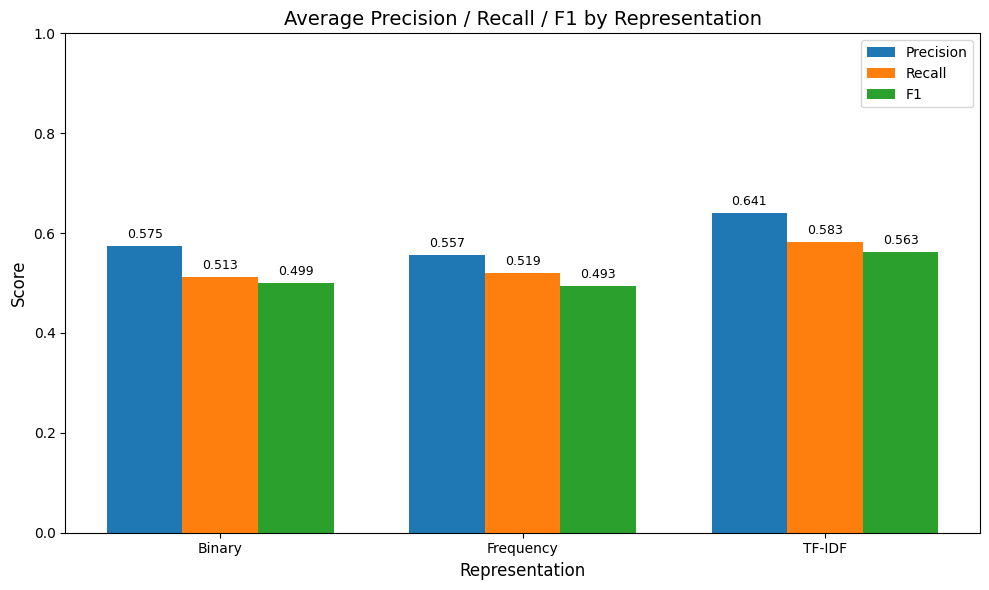

In [20]:
# Average metrics comparison across representations
avg_metrics = {}
for rep_name in rep_names:
    avg_metrics[rep_name] = {
        'Precision': np.mean([evaluation_results[rep_name][q_id]['precision'] for q_id in query_ids]),
        'Recall': np.mean([evaluation_results[rep_name][q_id]['recall'] for q_id in query_ids]),
        'F1': np.mean([evaluation_results[rep_name][q_id]['f1'] for q_id in query_ids])
    }

avg_df = pd.DataFrame(avg_metrics).T
print("Average Metrics Across All Queries:")
display(avg_df.round(4))

# Grouped bar chart for averages
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(rep_names))
width = 0.25

for i, metric in enumerate(['Precision', 'Recall', 'F1']):
    values = [avg_metrics[r][metric] for r in rep_names]
    bars = ax.bar(x + i * width, values, width, label=metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Representation', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Average Precision / Recall / F1 by Representation', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(rep_names)
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

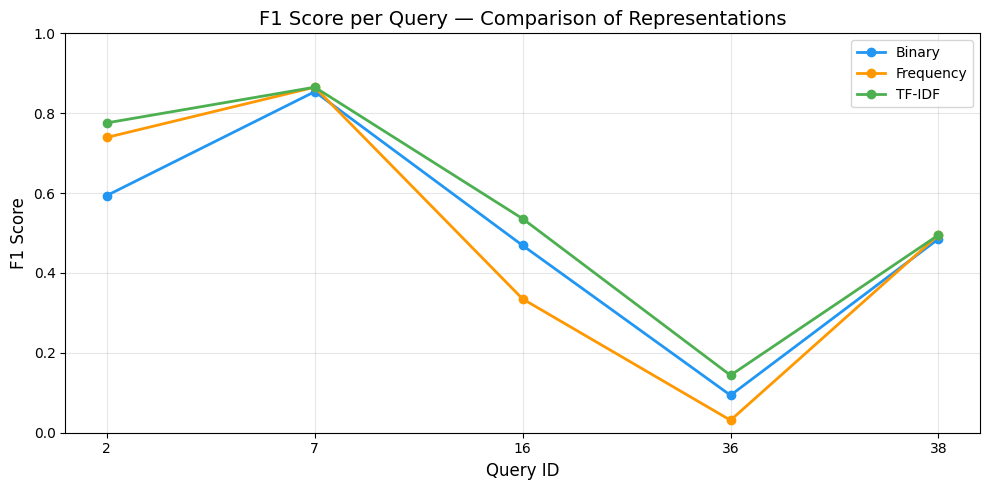

In [ ]:
# F1 comparison across queries - line chart
fig, ax = plt.subplots(figsize=(10, 5))

for rep_name, color in zip(rep_names, colors):
    f1_values = [evaluation_results[rep_name][q_id]['f1'] for q_id in query_ids]
    ax.plot(query_ids, f1_values, marker='o', label=rep_name, color=color, linewidth=2)

ax.set_xlabel('Query ID', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score per Query — Comparison of Representations', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

---
## Discussion and Conclusions

### Key Findings

**TF-IDF consistently outperforms Binary and Frequency representations.** This is expected because TF-IDF applies Inverse Document Frequency weighting, which downweights common terms (e.g., 'protein', 'cell', 'study') that appear in almost every biomedical document. This helps the model focus on distinguishing terms that truly characterize a query's intent.

**Binary representation yields the lowest precision.** Since binary vectors only encode whether a term is present (1) or absent (0), they lose information about how important a term is to a specific document. A document mentioning 'transgenic mice' once is treated the same as one that discusses it extensively. This leads to many false positives in the top-100 results.

**Frequency (raw count) representation is a middle ground.** It captures term importance better than binary by considering how often terms appear, but it tends to favor longer documents that naturally contain more word occurrences. This introduces a length bias that TF-IDF corrects through normalization.

**Recall varies significantly across queries.** Queries with a larger pool of relevant documents in the gold standard (e.g., query 38 with 300+ relevant docs) naturally have lower recall when retrieving only 100 documents, compared to queries with a smaller relevant set (e.g., query 2 with ~65 relevant docs).

### What Worked Well
- The text cleaning pipeline (lemmatization + stopword removal) from Parts A/B was effective at reducing noise and creating a focused vocabulary.
- Cosine similarity is well-suited for comparing sparse high-dimensional vectors, as it is scale-invariant and captures angular similarity.
- Combining query fields (title + need + context) provided a richer query representation than using the title alone.

### Possible Improvements
- **BM25 ranking**: A probabilistic ranking function that handles term saturation and document length normalization better than raw TF-IDF.
- **Query expansion**: Using synonyms or related terms (as explored in Part A with WordNet) to capture vocabulary mismatch between queries and documents.
- **Increasing k**: Retrieving more than 100 documents would improve recall, especially for queries with large relevant sets.
- **Learning-to-rank**: Training a model to re-rank initial retrieval results using additional features (e.g., document length, section overlap, named entities).

---
## סיכום הפרויקט

**האם התוצר של הלמידה מבוססת פרויקט שקיימנו במסגרת הקורס אחזור וכריית מידע שימושי, ויכול לשמש אותנו גם בפרויקטים עתידיים?**

בהחלט כן. הפרויקט הזה לימד אותנו לא רק את התיאוריה של אחזור מידע, אלא נתן לנו ניסיון מעשי בבניית צינור עיבוד שלם (pipeline) מקצה לקצה - מניקוי נתונים גולמיים, דרך ייצוג וקטורי, ועד חיפוש והערכת תוצאות.

**הכלים והמיומנויות שרכשנו ישימים במגוון רחב של פרויקטים עתידיים:**

1. **עיבוד שפה טבעית (NLP):** צינור הניקוי שבנינו - טוקניזציה, למטיזציה, הסרת מילות עצירה - הוא הבסיס לכל משימת NLP, בין אם מדובר בסיווג טקסטים, ניתוח סנטימנט, או מערכות צ'אטבוט.

2. **ייצוג וקטורי של טקסט:** השיטות שלמדנו (Binary, Frequency, TF-IDF) הן אבני בניין מרכזיות גם בפרויקטים של למידת מכונה ולמידה עמוקה. הבנת היתרונות והחסרונות של כל ייצוג עוזרת לנו לבחור את הגישה הנכונה בהתאם למשימה.

3. **הערכת מודלים:** חישוב Precision, Recall ו-F1 הוא מיומנות בסיסית שנדרשת בכל פרויקט של למידת מכונה - מזיהוי תמונות ועד אבחון רפואי. היכולת להעריך ולהשוות ביצועים של מודלים שונים היא קריטית.

4. **עבודה עם נתונים ביו-רפואיים:** הניסיון בעבודה עם מסמכים רפואיים, שאילתות מחקריות, ושיפוט רלוונטיות (qrel) רלוונטי במיוחד עבורנו כסטודנטים בפקולטה לטכנולוגיות דיגיטליות ברפואה. מיומנויות אלה ישמשו אותנו בפרויקטים עתידיים בתחום ה-Health Informatics ובניית מערכות תמיכה בהחלטות קליניות.

5. **חשיבה ביקורתית:** הפרויקט לימד אותנו לנתח תוצאות, לזהות חולשות, ולהציע שיפורים - מיומנות חיונית לכל מהנדס/ת תוכנה.

לסיכום, הפרויקט סיפק לנו בסיס מעשי חזק שנוכל לבנות עליו בפרויקטים עתידיים, הן בתחום אחזור המידע והן בתחומים רחבים יותר של מדעי הנתונים ולמידת מכונה.